
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [191]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(context="paper", style="white", font="Times New Roman")

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.


  



## <span style="color:green; font-size: 30px">Solución<span>

In [ ]:
df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### <span style="color:#7EED6D; font-size:20px">Analisis Estadistico<span>

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [79]:
df.describe(include=str)

,origin,name
count,398,398
unique,3,305
top,usa,ford pinto
freq,249,6


<span style="color:#7EED6D; font-size:20px">Graficas Analiticas<span>

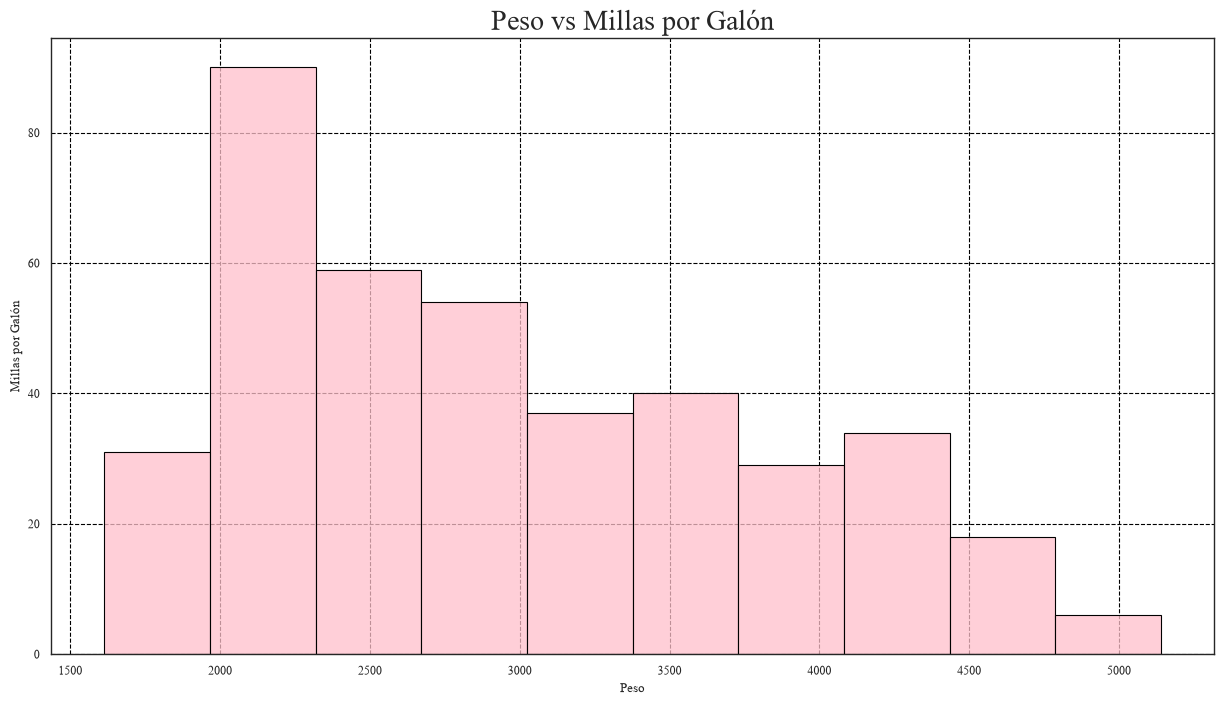

In [ ]:
fig, axes = plt.subplots(figsize=(15, 8))
sns.histplot(x="weight", data=df, color="pink", edgecolor="black")
plt.title("Peso vs Millas por Galón", fontsize=20)
plt.xlabel("Peso")
plt.ylabel("Millas por Galón")
plt.grid(color="black", linestyle="--")
plt.show()

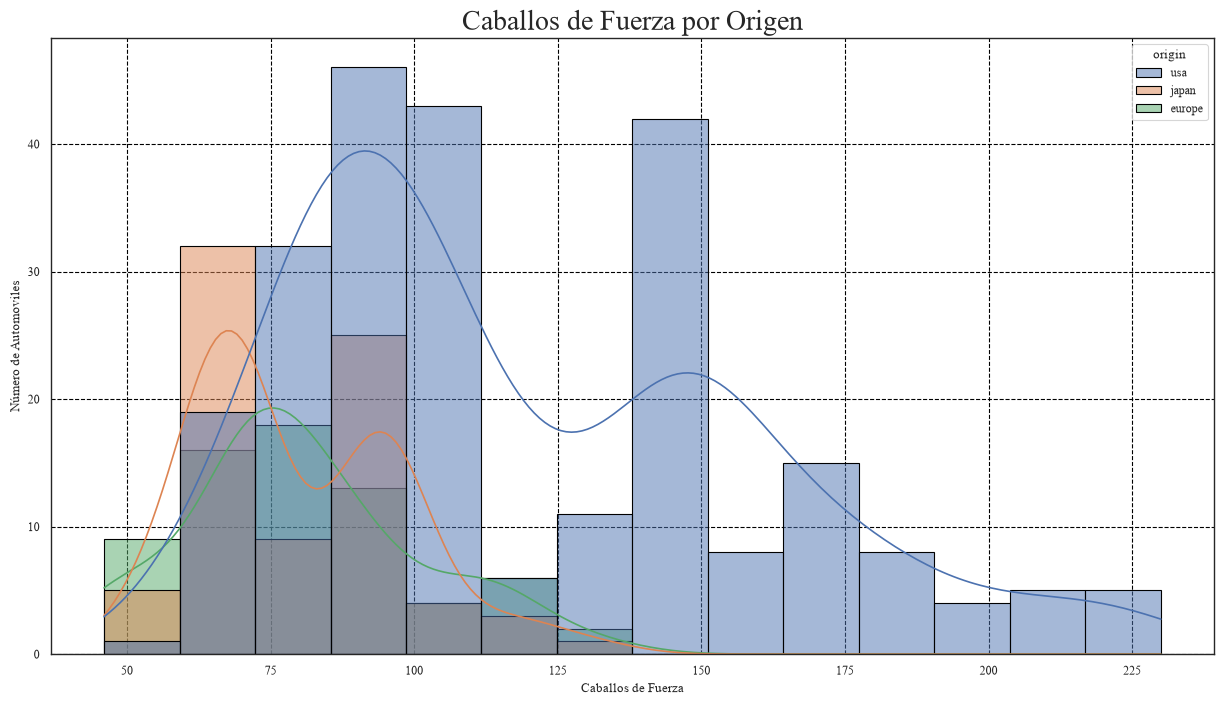

In [172]:
fig, axes = plt.subplots(figsize=(15, 8))
sns.histplot(
    x="horsepower", data=df, hue="origin", edgecolor="black", alpha=0.5, kde=True
)
plt.title("Caballos de Fuerza por Origen", fontsize=20)
plt.xlabel("Caballos de Fuerza")
plt.ylabel("Número de Automoviles")
plt.grid(color="black", linestyle="--")
plt.show()

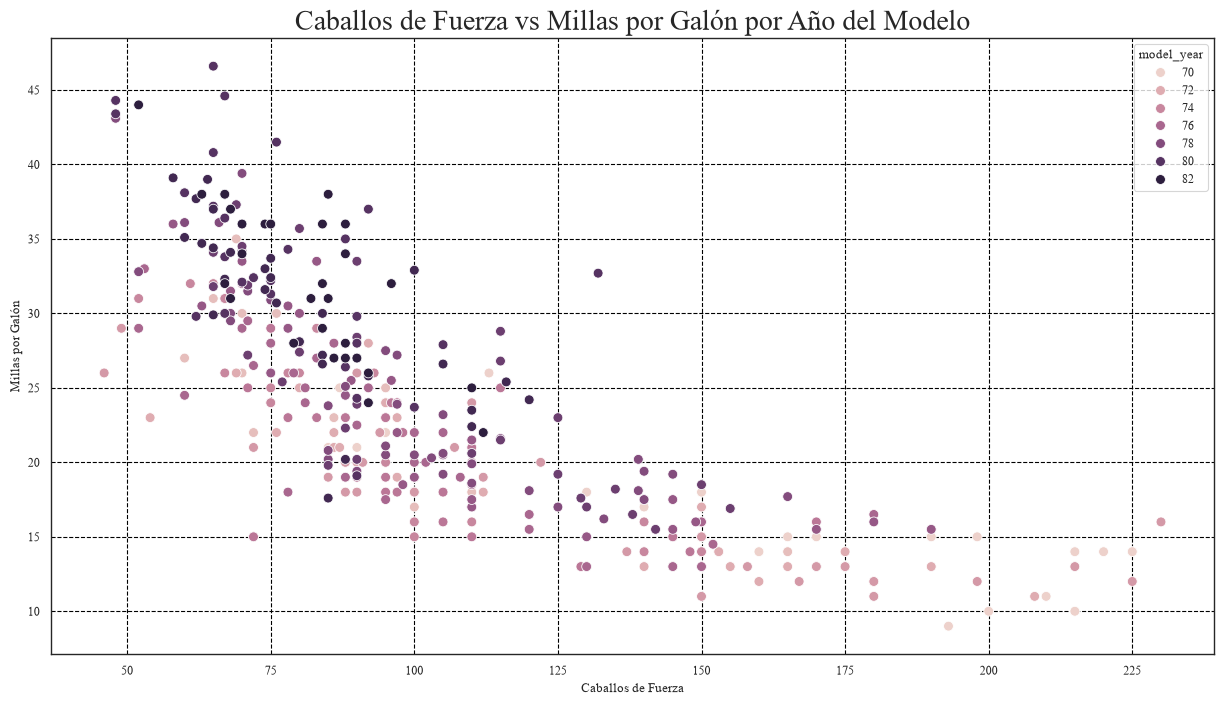

In [173]:
df_model_year = df[["model_year", "horsepower", "mpg"]]
fig, axes = plt.subplots(figsize=(15, 8))
sns.scatterplot(x="horsepower", y="mpg", data=df_model_year, hue="model_year", s=50)
plt.title("Caballos de Fuerza vs Millas por Galón por Año del Modelo", fontsize=20)
plt.xlabel("Caballos de Fuerza")
plt.ylabel("Millas por Galón")
plt.grid(color="black", linestyle="--")
plt.show()

<span style="color:#7EED6D; font-size:20px">Regresion lineal de Orden 1 (Linea recta) y Orden 2 (Polinomio de grado 2) al 95% de C.L<span>

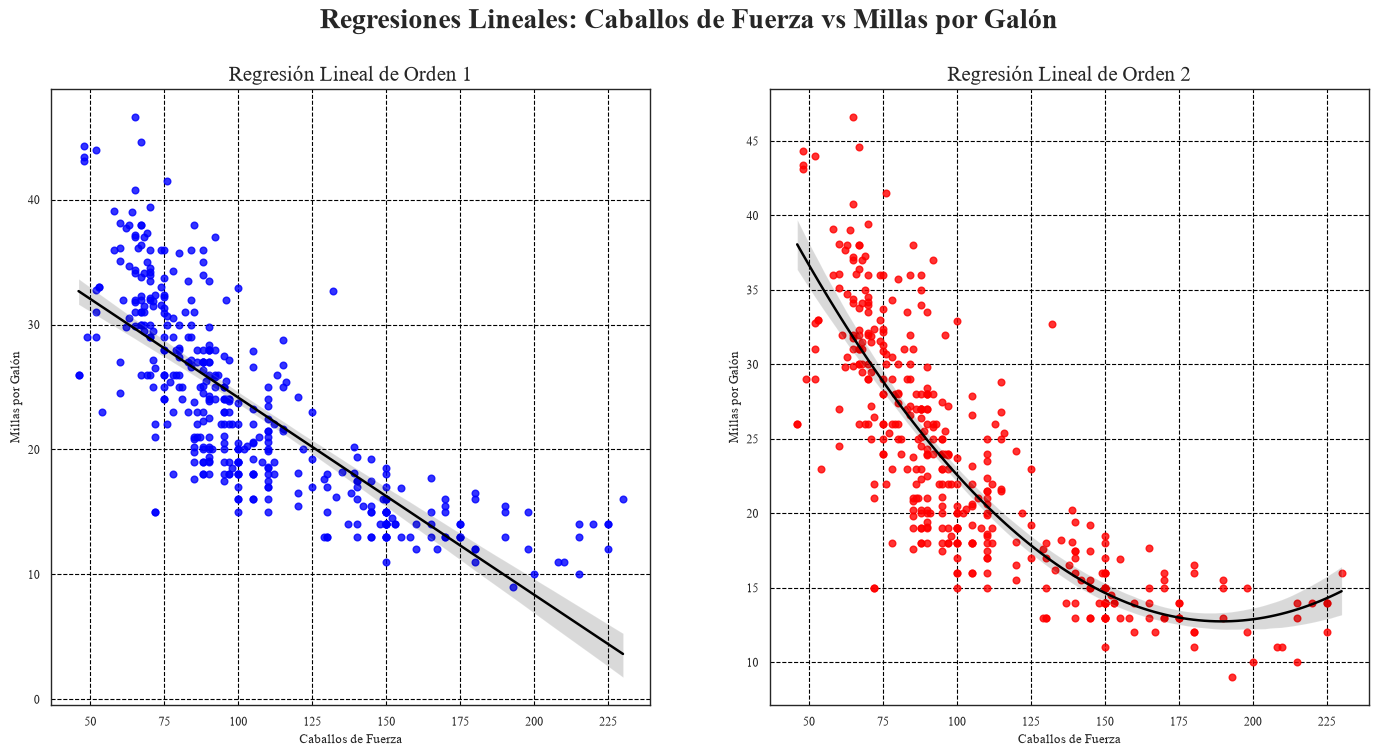

In [176]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
plt.suptitle(
    "Regresiones Lineales: Caballos de Fuerza vs Millas por Galón",
    fontsize="20",
    fontweight=700,
)
sns.regplot(
    x="horsepower",
    y="mpg",
    data=df,
    ax=axes[0],
    order=1,
    ci=95,
    color="blue",
    line_kws={"color": "black"},
)
sns.regplot(
    x="horsepower",
    y="mpg",
    data=df,
    ax=axes[1],
    order=2,
    ci=95,
    color="red",
    line_kws={"color": "black"},
)
axes[0].set_title("Regresión Lineal de Orden 1", fontsize="15", fontweight=400)
axes[0].set_xlabel("Caballos de Fuerza")
axes[0].set_ylabel("Millas por Galón")
axes[0].grid(color="black", linestyle="--")
axes[1].set_title("Regresión Lineal de Orden 2", fontsize="15", fontweight=400)
axes[1].set_xlabel("Caballos de Fuerza")
axes[1].set_ylabel("Millas por Galón")
axes[1].grid(color="black", linestyle="--")
plt.show()

MUY BIEN

### <span style="color:#7EED6D; font-size:20px">Reproducción de la Figura<span>

El objetivo es replicar la figura 6 del trabajo **[Singlet-doublet Dirac dark matter and neutrino masses](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029#f6)** 

<img src="Images/figura_6_replicar.png" alt="Figura 6" width="500" height="400" style="display: block; margin: 0 auto;">

* $M_N=h_s\dfrac{v_s}{\sqrt{2}}$ 
* $v_s =$ vS
* $h_s=$ YRC
* $M_\Psi=$ MDF  
* $M_{\chi_1^0}=$ mChi1
* $\Omega_{\chi_1^0}=$ Omega
* $\Omega_{DM}=0.12$

In [156]:
df_dirac = pd.read_csv(r"C:\Users\PC\Downloads\general-scan.csv").drop(
    columns=["Unnamed: 0"]
)

df_dirac["M_N"] = df_dirac["YRC"] * df_dirac["vS"] / np.sqrt(2)
df_dirac["M_Psi"] = df_dirac["MDF"]

# Filtro los elementos que no cumplen la condicion (Leyenda Azul de la grafica)
df_dirac = df_dirac[
    (df_dirac["Omega"] >= 0.117) & (df_dirac["Omega"] <= 0.123)
].reset_index(drop=True)

df_dirac.head()

,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,YRD,...,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg,M_N,M_Psi
0,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,0.002169,...,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000,7414.553232,1092.250036
1,760.803107,8.373266e+07,8.373266e+07,0.028820,0.028820,0.000551,0.0,0.075695,165.045833,0.000172,...,1.291282e-20,2.580000e-31,0.001647,-0.999999,-0.999999,-0.001647,0.000340,0.002827,58.392463,760.803107
2,8341.240595,7.114470e+07,7.114470e+07,0.001867,0.001867,0.003031,0.0,0.097810,209.997674,0.000289,...,1.372138e-22,2.590000e-31,0.013820,-0.999905,-0.999905,-0.013820,0.000757,0.002814,95.091091,8341.240595
3,1062.849287,1.201702e+06,1.201702e+06,0.004802,0.004802,0.000559,0.0,0.844567,4300.673519,0.278648,...,2.416634e-14,2.330000e-26,1.000000,-0.000038,0.000038,1.000000,0.002827,0.000000,1841.625196,1062.849287
4,1114.709479,9.598878e+06,9.598878e+06,0.002607,0.002607,0.018524,0.0,0.031628,12579.718965,0.013612,...,3.330760e-17,1.930000e-26,0.999935,-0.011434,0.011434,0.999935,0.002832,0.000000,4601.668783,1114.709479


In [ ]:
# Filtro para el Trapezoide Izquierdo Superior
filtro_2 = df_dirac[
    (df_dirac["M_N"] >= df_dirac["M_Psi"]) & (df_dirac["M_Psi"] < 1000)
].index
df_dirac = df_dirac.drop(filtro_2).reset_index(drop=True)

# Filtro para el Trapezoide Derecho Superior
mpsi_nodes = np.array(
    [1250, 1500, 1800, 2200, 2700, 3200, 3800, 4500, 5500, 7000, 8500, 10000]
)
mn_envelope_nodes = np.array(
    [1250, 1350, 1450, 1500, 1800, 2000, 1900, 1850, 1700, 1600, 1500, 1400]
)
mn_limite_data = np.interp(df_dirac["MDF"], mpsi_nodes, mn_envelope_nodes)

condicion_zona_roja = (df_dirac["MDF"] > 1250) & (df_dirac["M_N"] > mn_limite_data)

df_dirac = df_dirac[~condicion_zona_roja]


In [ ]:
color_red = "#FA8072"
color_green = "#4da64d"
color_blue = "#3333ff"
px = 1 / plt.rcParams["figure.dpi"]

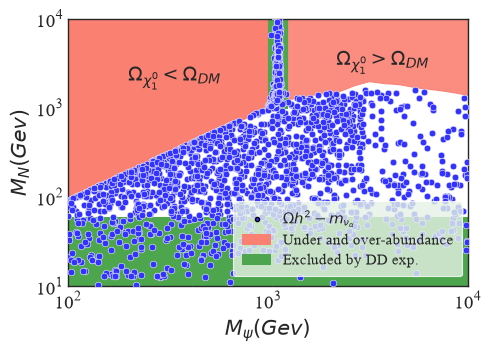

In [212]:
fig, axes = plt.subplots(figsize=(500 * px, 361 * px))
sns.scatterplot(
    data=df_dirac, x=df_dirac["M_Psi"], y=df_dirac["M_N"], color=color_blue, zorder=3
)

# Trapezoide Rojo Izquierda Superior
x_izquierda = np.logspace(2, 3, 200)
axes.fill_between(
    x=x_izquierda,
    y1=x_izquierda,
    y2=10000,
    color=color_red,
)
# Trapezoide Rojo Derecha Superior
x_right = np.logspace(np.log10(1250), 4, 150)
mn_border = np.interp(x_right, mpsi_nodes, mn_envelope_nodes)
axes.fill_between(
    x_right,
    y1=mn_border,
    y2=10000,
    color=color_red,
    alpha=0.9,
    zorder=0,
)

# Rectangulo Verde Superior
axes.fill_between(
    x=np.array([1000, 1250]),
    y1=np.array([1000]),
    y2=np.array([100000]),
    color=color_green,
)

# Rectangulo Verde Inferior
axes.axhspan(ymin=0, ymax=60, color=color_green, zorder=1)

# Ejes
axes.set_xscale("log")
axes.set_xlim(100, 10000)
axes.set_xlabel(r"$M_{\psi}(Gev)$", fontsize=15)
axes.set_yscale("log")
axes.set_ylim(10, 10000)
axes.set_ylabel("$M_N(Gev)$", fontsize=15)
axes.tick_params(axis="both", which="major", labelsize=14, direction="in", length=7, width=1.2, color="black")


# Anotaciones
axes.text(200, 2000, r"$\Omega_{\chi_1^0} < \Omega_{DM}$", fontsize=14, zorder=5)
axes.text(2200, 3000, r"$\Omega_{\chi_1^0} > \Omega_{DM}$", fontsize=14, zorder=5)

# Elementos de la Leyenda
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=color_blue,
        markersize=3,
        label=r"$\Omega h^2 - m_{\nu_\alpha}$",
    ),
    Patch(facecolor=color_red, edgecolor="none", label="Under and over-abundance"),
    Patch(facecolor=color_green, edgecolor="none", label="Excluded by DD exp."),
]

# Leyenda
axes.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.70, 0.01),
    frameon=True,
    facecolor="#E6F2E6",  # Fondo verde/gris claro idéntico a la imagen
    edgecolor="white",
    fontsize=10.5,
    borderpad=0.6,
    labelspacing=0.4,
)

# Guardar y Mostrar
plt.tight_layout()
plt.savefig("Images/Replica.png", bbox_inches="tight", pad_inches=0.03)
plt.show()


###  <span style="color:#7EED6D; font-size:20px">Comparacion entre Graficas<span>

<table>
  <tr>
    <th>Original</th>
    <th>Replica</th>
  </tr>
  <tr>
    <td><img src="Images\figura_6_replicar.png"></td>
    <td><img src="Images/Replica.png"></td>
  </tr>
</table>

NO SE VE LA COMPARACIÓN.
NOTA 5.0